# Telco Customer Churn — Modeling & Evaluation

**Author:** Allison Schiltz

**Objectives**:
- Build two models to predict `Churn`:
    - For both models: **Class weights** will be used to adjust for imbalanced data and **regularization** will be used to prevent overfitting.
    - **Logistic Regression** with regularization as a baseline and for interpretability. A baseline model helps determine whether a more complex model adds value. 
    - **Gradient Boosted Trees** using LightGBM for higher predictive power
    - **Optuna** will be using for hyperparameter tuning and cross-validation
- **Strategy**: 
    - Use a train/test split strategy with cross-validation (CV) plus a final holdout set.
    - Perform cross-validation on the training data to tune hyperparameters.
    - Evaluate the final model on the untouched test set (holdout) for an unbiased performance estimate.
- Prioritize **recall ≥ 0.70**, **precision ≥ 0.5** and **ROC-AUC > 0.75**
    - **Recall** to identify as many customers at risk of churning as possible (minimizing false negatives). This is important in churn scenarios, where missing a potential churner can be costly for the business.
    - **Precision** to limit how many non-churners we incorrectly flag as likely churners (minimizing false positives). A minimum precision of 0.50 means that at least half of the customers we target are truly at risk, which helps ensure retention resources are used efficiently. Outreach offers, discounts, and service interventions are costly, so enforcing a precision threshold helps keep the churn program scalable and cost-effective.
    - **ROC-AUC** to measure the model’s overall discriminative power to distinguish between churners and non-churners across all thresholds.

**Workflow:**
- Load preprocessed train/test splits and pruned feature sets; clean feature names for LightGBM.
- Establish baselines (dummy classifier; regularized logistic regression) and define shared CV strategy.
- Train/tune Logistic Regression across multiple feature sets using class weights + regularization.
- Train/tune LightGBM (Optuna + CV), using `scale_pos_weight` for class imbalance and optimizing Average Precision (PR-AUC).
- Evaluate models using pooled out-of-fold (OOF) probabilities at a baseline threshold (0.50) and with a constraint-based threshold chosen to maximize recall subject to precision ≥ 0.50 (with a buffer).
- Select a final model, refit it on full training data, and evaluate once on the untouched test set (metrics + confusion matrix).
- Interpret top logistic coefficients via odds ratios and export tables/figures to `reports/`.

## 0. Environment & Imports

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from optuna.samplers import TPESampler
from optuna.integration import lightgbm as lgb_optuna
import optuna.integration.lightgbm as lgb_optuna

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    recall_score, roc_auc_score, precision_score, confusion_matrix, roc_curve, precision_recall_curve, make_scorer, average_precision_score
)
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold


import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

In [3]:
import sys
print(sys.executable)

/Users/Allison/Code/.venv/bin/python


## 1. Load Data
- Load combined, preprocessed features and target labels needed for modeling.
- Load column-role manifest (ID, target, numeric, categorical, booleans)

In [4]:
# Load Training features
X_train_final = pd.read_csv('../data/processed/X_train_final.csv')
# Load Training target
y_train = pd.read_csv('../data/processed/y_train.csv')

# Load Test features
X_test_final = pd.read_csv('../data/processed/X_test_final.csv')
# Load Test target
y_test = pd.read_csv('../data/processed/y_test.csv')

# Load column role manifest
column_roles = pd.read_csv('../references/telco_column_role_manifest.csv')

# Load pruned feature sets based on EDA findings
pruned_features_monthly_charges_bin = pd.read_csv('../data/processed/pruned_features_monthly_charges_bin.csv', header=None).squeeze().tolist()

pruned_features_internet_service = pd.read_csv('../data/processed/pruned_features_internet_service.csv', header=None).squeeze().tolist()

pruned_features_all_add_ons = pd.read_csv('../data/processed/pruned_features_all_add_ons.csv', header=None).squeeze().tolist()

In [5]:
# Clean column names to remove special JSON characters for LightGBM compatibility
import re

def clean_lgbm_feature_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'["\\{}\[\]:,]', '_', str(col)) for col in df.columns
    ]
    return df

# Cleaned versions for LightGBM
X_train_final_clean = clean_lgbm_feature_names(X_train_final)
X_test_final_clean = clean_lgbm_feature_names(X_test_final)


In [6]:
# Extract target column

y_train = y_train['Churn']
y_test = y_test['Churn']

In [7]:
print(X_train_final_clean.shape)
print(y_train.shape, '\n')

print(X_test_final_clean.shape)
print(y_test.shape)

(5625, 41)
(5625,) 

(1407, 41)
(1407,)


In [8]:
print("X_train_final head\n", X_train_final_clean.head())
print("X_test_final head\n", X_test_final_clean.head())
print("y_train head\n", y_train.head())
print("y_test head\n", y_test.head(), '\n')
print('X_train_final_clean dtypes:', X_train_final_clean.dtypes, '\n')
print('X_test_final_clean dtypes:', X_test_final_clean.dtypes, '\n')

X_train_final head
    Unnamed_ 0    tenure  MonthlyCharges  TotalCharges  total_services_eng  \
0        1408  1.321816        0.981556      1.659900            1.269948   
1        6992 -0.267410       -0.971546     -0.562252           -0.671868   
2        3349  1.444064        0.837066      1.756104            0.784494   
3        4486 -1.204646        0.641092     -0.908326           -0.186414   
4        3535  0.669826       -0.808787     -0.101561           -0.671868   

   gender_Male  SeniorCitizen_Yes  Partner_Yes  Dependents_Yes  \
0         True              False         True            True   
1         True              False        False           False   
2        False              False         True           False   
3         True              False        False           False   
4        False              False         True           False   

   PhoneService_Yes  ...  PaymentMethod_Mailed_check  tenure_group_eng_13-24  \
0              True  ...                

In [9]:
# Save processed datasets with cleaned column names for LightGBM
X_train_final_clean.to_csv('../data/processed/X_train_final_clean.csv', index=False)
X_test_final_clean.to_csv('../data/processed/X_test_final_clean.csv', index=False)

# Save extracted target variables
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

## 2. Baselines
1. Stratified baseline classifier:
- Assign class labels at random according to the class proportions in the training data
- Calculate and record metrics: recall, precision, ROC-AUC, PR-AUC. This sets a minimum performance bar.
2. Logistic regression baseline (with regularization):
- Train a logistic regression model using default or simple regularization (e.g., L2 penalty, class_weight="balanced").
- Evaluate on the validation or test set.
- Record the same metrics: recall, precision, ROC-AUC, PR-AUC.


In [10]:
# Stratified baseline classifier with all features
from sklearn.dummy import DummyClassifier

# Instantiate and fit classifier
dummy = DummyClassifier(strategy="stratified", random_state=SEED)
dummy.fit(X_train_final_clean, y_train.values.ravel())

# Predict class labels and class probabilities
y_pred_dummy = dummy.predict(X_test_final_clean)
y_proba_dummy = dummy.predict_proba(X_test_final_clean)[:, 1]
pr_auc_dummy = average_precision_score(y_test.values.ravel(), y_proba_dummy)

# Calculate and print metrics
print("- Accuracy:", round(dummy.score(X_test_final_clean, y_test), 4))
print("- Recall:", round(recall_score(y_test, y_pred_dummy), 4))
print("- Precision:", round(precision_score(y_test, y_pred_dummy), 4))
print("- ROC-AUC:", round(roc_auc_score(y_test, y_proba_dummy), 4))
print(f"- PR-AUC (Average Precision): {pr_auc_dummy:.4f}")

- Accuracy: 0.6148
- Recall: 0.2781
- Precision: 0.2766
- ROC-AUC: 0.5074
- PR-AUC (Average Precision): 0.2688


### Logistic Regression — Shared CV and Hyperparameter Grid Set Up

In [11]:
# Define StratifiedKFold cross-validator (cv) for use in both Logistic Regression and LightGBM
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring="average_precision"

# Define parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],           # Regularization strength
    'penalty': ['l2', 'l1'],                 # L1 and L2 regularization types
    'solver': ['liblinear', 'saga'],               # 'liblinear' and 'saga' support L1 and L2
    'class_weight': ['balanced']       # Handle class imbalance
}

### Logistic Regression Model: All features

In [12]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: All features

# Set up logistic regression and grid search
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
grid = GridSearchCV(logreg, param_grid, scoring=scoring, cv=cv, n_jobs=-1)

# Fit on training data
grid.fit(X_train_final_clean, y_train)

# Best model
best_logreg = grid.best_estimator_


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/Allison/Code/.venv/lib/python3.11/site-pack

In [13]:
print(best_logreg)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Binned Monthly Charges

In [14]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Monthly Charges (no add-ons except Online Security)

# Subset the full training and test sets using the pruned feature list
X_train_monthly_charges_bin = X_train_final_clean[pruned_features_monthly_charges_bin]

# Set up logistic regression and grid search
monthly_charges_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
monthly_charges_grid = GridSearchCV(monthly_charges_logreg, param_grid, scoring=scoring, cv=cv, n_jobs=-1)

# Fit on training data
monthly_charges_grid.fit(X_train_monthly_charges_bin, y_train)

# Best model
best_logreg_monthly_charges_bin = monthly_charges_grid.best_estimator_



In [15]:
print("Best monthly charges hyperparam for log reg model:\n", best_logreg_monthly_charges_bin)

Best monthly charges hyperparam for log reg model:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Logistic Regression Model: Internet Service (no add-ons)

In [16]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - Internet Service (no add-ons)

# Subset the full training and test sets using the pruned feature list
X_train_internet_service = X_train_final_clean[pruned_features_internet_service]

# Set up logistic regression and grid search
internet_service_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
internet_service_grid = GridSearchCV(internet_service_logreg, param_grid, scoring=scoring, cv=cv, n_jobs=-1)

# Fit on training data
internet_service_grid.fit(X_train_internet_service, y_train if isinstance(y_train, pd.Series) else y_train)

# Best model
best_logreg_internet_service = internet_service_grid.best_estimator_



In [17]:
print("Best logreg internet service hyperparameters:\n", best_logreg_internet_service)

Best logreg internet service hyperparameters:
 LogisticRegression(C=1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='saga')


### Logistic Regression Model: All Add-Ons, no Internet Service

In [18]:
# Logistic Regression Model with Regularization, Hyperparameter Tuning, and Class Weighting: Pruned features - All Add-Ons, no InternetService

# Subset the full training and test sets using the pruned feature list
X_train_all_add_ons = X_train_final_clean[pruned_features_all_add_ons]


# Set up logistic regression and grid search
all_add_ons_logreg = LogisticRegression(max_iter=1000, random_state=SEED)
all_add_ons_grid = GridSearchCV(all_add_ons_logreg, param_grid, scoring=scoring, cv=cv, n_jobs=-1)

# Fit on training data
all_add_ons_grid.fit(X_train_all_add_ons, y_train)

# Best model
best_logreg_all_add_ons = all_add_ons_grid.best_estimator_


In [19]:
print("Best logreg all add ons hyperparameters:\n", best_logreg_all_add_ons)

Best logreg all add ons hyperparameters:
 LogisticRegression(C=10, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='liblinear')


### Evaluate Logistic Regression Model: All features

In [20]:
# Evaluate the All Features Logistic Regression model using the best parameters
print("Results for All Features Model")
print("Best parameters:", grid.best_params_)
print("Mean cross-validated recall:", round(grid.best_score_, 4))

cv_precision = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=cv, scoring='precision')

print("Mean cross-validated precision:", round(cv_precision.mean(), 4))

cv_roc_auc = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=cv, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(cv_roc_auc.mean(), 4))

cv_pr_auc = cross_val_score(best_logreg, X_train_final_clean, y_train, cv=cv, scoring=make_scorer(average_precision_score))

print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc.mean(), 4))

Results for All Features Model
Best parameters: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.6663
Mean cross-validated precision: 0.5251
Mean cross-validated ROC-AUC: 0.8492
Mean cross-validated PR-AUC (Average Precision): 0.4738


### Evaluate Logistic Regression Model: Binned Monthly Charges

In [21]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Pruned Monthly Charges Model")
print("Best parameters:", monthly_charges_grid.best_params_)
print("Mean cross-validated recall:", round(monthly_charges_grid.best_score_, 4))

monthly_charges_cv_precision = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=cv, scoring='precision')

print("Mean cross-validated precision:", round(monthly_charges_cv_precision.mean(), 4))
monthly_charges_cv_roc_auc = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=cv, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(monthly_charges_cv_roc_auc.mean(), 4))

cv_pr_auc_monthly_charges = cross_val_score(best_logreg_monthly_charges_bin, X_train_monthly_charges_bin, y_train, cv=cv, scoring=make_scorer(average_precision_score))

print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_monthly_charges.mean(), 4))

Results for Pruned Monthly Charges Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.6412
Mean cross-validated precision: 0.5204
Mean cross-validated ROC-AUC: 0.8436
Mean cross-validated PR-AUC (Average Precision): 0.4688


### Evaluate Logistic Regression Model: Internet Service

In [22]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for Internet Service Model")

print("Best parameters:", internet_service_grid.best_params_)

print("Mean cross-validated recall:", round(internet_service_grid.best_score_, 4))

internet_service_cv_precision = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=cv, scoring='precision')

print("Mean cross-validated precision:", round(internet_service_cv_precision.mean(), 4))

internet_service_cv_roc_auc = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=cv, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(internet_service_cv_roc_auc.mean(), 4))

cv_pr_auc_internet_service = cross_val_score(best_logreg_internet_service, X_train_internet_service, y_train, cv=cv, scoring=make_scorer(average_precision_score))

print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_internet_service.mean(), 4))

Results for Internet Service Model
Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}
Mean cross-validated recall: 0.638
Mean cross-validated precision: 0.516
Mean cross-validated ROC-AUC: 0.8419
Mean cross-validated PR-AUC (Average Precision): 0.4665


### Evaluate Logistic Regression Model: All Add-Ons, no Internet Service

In [23]:
# Evaluate the best Logistic Regression model using the best parameters
print("Results for All Add-Ons Model")
print("Best parameters:", all_add_ons_grid.best_params_)
print("Mean cross-validated recall:", round(all_add_ons_grid.best_score_, 4))

all_add_ons_cv_precision = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='precision')

print("Mean cross-validated precision:", round(all_add_ons_cv_precision.mean(), 4))

all_add_ons_cv_roc_auc = cross_val_score(best_logreg_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='roc_auc')

print("Mean cross-validated ROC-AUC:", round(all_add_ons_cv_roc_auc.mean(), 4))

cv_pr_auc_all_add_ons = cross_val_score(best_logreg, X_train_all_add_ons, y_train, cv=cv, scoring=make_scorer(average_precision_score))

print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_all_add_ons.mean(), 4))

Results for All Add-Ons Model
Best parameters: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
Mean cross-validated recall: 0.6537
Mean cross-validated precision: 0.5255
Mean cross-validated ROC-AUC: 0.8467
Mean cross-validated PR-AUC (Average Precision): 0.4718


## 4. Advanced Models
- Tree-based gradient boosting with LightGBM
- Hyperparameter tuning (Oputuna) with cross-validation
- Early stopping / model selection criteria

In [24]:
# Set up Optuna LightGBM parameters shared across all trials, including scale_pos_weight for class imbalance and seeds for reproducibility

# compute class-imbalance ratio for LightGBM CV scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"n_neg={n_neg}, n_pos={n_pos}, scale_pos_weight={scale_pos_weight:.2f}")

params = {
    'objective': 'binary',
    'metric': 'average_precision',  # Use average_precision for PR-AUC optimization
    'verbosity': -1,
    'boosting_type': 'gbdt',
    'scale_pos_weight': scale_pos_weight,

    # extra seeds for reproducibility in LightGBM
    "seed": SEED,
    "feature_fraction_seed": SEED,
    "bagging_seed": SEED,
    "data_random_seed": SEED
}

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=SEED))
callbacks = [lgb.early_stopping(stopping_rounds=50, min_delta=0.0)]



[I 2026-02-13 13:52:20,355] A new study created in memory with name: no-name-e0ce3b4e-424f-44ac-997e-44a4872e478f


n_neg=4130, n_pos=1495, scale_pos_weight=2.76


### LightGBM Hyperparameter Tuning: All features

In [25]:
# LightGBM Model with Optuna Hyperparameter Tuning with Cross-Validation

# Prepare data for LightGBM (no need for label column in features)
X = X_train_final_clean  # Use cleaned DataFrame
y = y_train

# Run Optuna hyperparameter tuning with cross-validation
optuna_lgbm = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X, label=y),
    folds=cv,
    show_progress_bar=True,
    num_boost_round=1000,
    callbacks=callbacks,
    study=study
)
optuna_lgbm.run()


feature_fraction, val_score: -inf:   0%|          | 0/7 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.658497:  14%|#4        | 1/7 [00:02<00:15,  2.54s/it]

Early stopping, best iteration is:
[49]	valid's average_precision: 0.658497 + 0.0205775
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.662387:  29%|##8       | 2/7 [00:03<00:08,  1.71s/it]

Early stopping, best iteration is:
[36]	valid's average_precision: 0.662387 + 0.0167039
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411:  43%|####2     | 3/7 [00:04<00:05,  1.35s/it]

Early stopping, best iteration is:
[30]	valid's average_precision: 0.663411 + 0.0203023
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411:  57%|#####7    | 4/7 [00:05<00:03,  1.27s/it]

Early stopping, best iteration is:
[35]	valid's average_precision: 0.660213 + 0.0132901
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411:  71%|#######1  | 5/7 [00:07<00:02,  1.27s/it]

Early stopping, best iteration is:
[40]	valid's average_precision: 0.661963 + 0.01808
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411:  86%|########5 | 6/7 [00:08<00:01,  1.19s/it]

Early stopping, best iteration is:
[28]	valid's average_precision: 0.659342 + 0.0129744
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction, val_score: 0.663411: 100%|##########| 7/7 [00:09<00:00,  1.31s/it]


Early stopping, best iteration is:
[40]	valid's average_precision: 0.66172 + 0.0162274


num_leaves, val_score: 0.663411:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.663411:   5%|5         | 1/20 [00:03<00:58,  3.09s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.651449 + 0.0196103
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.663411:  10%|#         | 2/20 [00:06<00:54,  3.00s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.651449 + 0.0196103
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.663411:  15%|#5        | 3/20 [00:07<00:38,  2.29s/it]

Early stopping, best iteration is:
[15]	valid's average_precision: 0.660342 + 0.0216333
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.665841:  20%|##        | 4/20 [00:08<00:27,  1.69s/it]

Early stopping, best iteration is:
[63]	valid's average_precision: 0.665841 + 0.0128647
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.665841:  25%|##5       | 5/20 [00:09<00:22,  1.49s/it]

Early stopping, best iteration is:
[38]	valid's average_precision: 0.663904 + 0.0169097
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  30%|###       | 6/20 [00:10<00:19,  1.39s/it]

Early stopping, best iteration is:
[347]	valid's average_precision: 0.66921 + 0.0140541
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  35%|###5      | 7/20 [00:12<00:19,  1.53s/it]

Early stopping, best iteration is:
[347]	valid's average_precision: 0.66921 + 0.0140541
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  40%|####      | 8/20 [00:14<00:21,  1.83s/it]

Early stopping, best iteration is:
[16]	valid's average_precision: 0.662304 + 0.0219302
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  45%|####5     | 9/20 [00:17<00:21,  1.97s/it]

Early stopping, best iteration is:
[347]	valid's average_precision: 0.66921 + 0.0140541


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.669210:  50%|#####     | 10/20 [00:24<00:36,  3.66s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.660352 + 0.0187827


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Training until validation scores don't improve for 50 rounds


num_leaves, val_score: 0.669210:  55%|#####5    | 11/20 [00:29<00:36,  4.01s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.652262 + 0.0177742
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  60%|######    | 12/20 [00:33<00:31,  3.96s/it]

Early stopping, best iteration is:
[17]	valid's average_precision: 0.651449 + 0.0196103
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  65%|######5   | 13/20 [00:35<00:23,  3.37s/it]

Early stopping, best iteration is:
[41]	valid's average_precision: 0.659323 + 0.0175091
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  70%|#######   | 14/20 [00:40<00:23,  3.89s/it]

Early stopping, best iteration is:
[38]	valid's average_precision: 0.661054 + 0.0179279
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  75%|#######5  | 15/20 [00:41<00:15,  3.09s/it]

Early stopping, best iteration is:
[79]	valid's average_precision: 0.666435 + 0.0150996
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  80%|########  | 16/20 [00:43<00:11,  2.80s/it]

Early stopping, best iteration is:
[63]	valid's average_precision: 0.665841 + 0.0128647
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  85%|########5 | 17/20 [00:48<00:10,  3.46s/it]

Early stopping, best iteration is:
[16]	valid's average_precision: 0.659663 + 0.0214073
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  90%|######### | 18/20 [00:50<00:05,  2.85s/it]

Early stopping, best iteration is:
[38]	valid's average_precision: 0.661385 + 0.0162359
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210:  95%|#########5| 19/20 [00:53<00:03,  3.08s/it]

Early stopping, best iteration is:
[37]	valid's average_precision: 0.662977 + 0.0163017
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
num_leaves, val_score: 0.669210: 100%|##########| 20/20 [00:55<00:00,  2.78s/it]


Early stopping, best iteration is:
[172]	valid's average_precision: 0.667618 + 0.0105353


bagging, val_score: 0.669210:   0%|          | 0/10 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.669210:  10%|#         | 1/10 [00:02<00:22,  2.55s/it]

Early stopping, best iteration is:
[245]	valid's average_precision: 0.668879 + 0.0147041
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.669560:  20%|##        | 2/10 [00:04<00:17,  2.16s/it]

Early stopping, best iteration is:
[351]	valid's average_precision: 0.66956 + 0.0145413
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670166:  30%|###       | 3/10 [00:06<00:14,  2.02s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670166 + 0.0136932
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670166:  40%|####      | 4/10 [00:07<00:11,  1.85s/it]

Early stopping, best iteration is:
[315]	valid's average_precision: 0.669868 + 0.0137302
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670166:  50%|#####     | 5/10 [00:08<00:07,  1.56s/it]

Early stopping, best iteration is:
[278]	valid's average_precision: 0.669594 + 0.013808
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670166:  60%|######    | 6/10 [00:09<00:05,  1.36s/it]

Early stopping, best iteration is:
[321]	valid's average_precision: 0.669469 + 0.0140578
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670166:  70%|#######   | 7/10 [00:11<00:03,  1.29s/it]

Early stopping, best iteration is:
[315]	valid's average_precision: 0.670117 + 0.0141646
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670166:  80%|########  | 8/10 [00:12<00:02,  1.24s/it]

Early stopping, best iteration is:
[314]	valid's average_precision: 0.670048 + 0.0141952
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670166:  90%|######### | 9/10 [00:13<00:01,  1.15s/it]

Early stopping, best iteration is:
[259]	valid's average_precision: 0.668659 + 0.0146204
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
bagging, val_score: 0.670166: 100%|##########| 10/10 [00:14<00:00,  1.42s/it]


Early stopping, best iteration is:
[275]	valid's average_precision: 0.668319 + 0.0167783


feature_fraction_stage2, val_score: 0.670166:   0%|          | 0/6 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670166:  17%|#6        | 1/6 [00:01<00:06,  1.24s/it]

Early stopping, best iteration is:
[278]	valid's average_precision: 0.669903 + 0.0142391
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670166:  33%|###3      | 2/6 [00:02<00:05,  1.25s/it]

Early stopping, best iteration is:
[321]	valid's average_precision: 0.670111 + 0.0142908
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670166:  50%|#####     | 3/6 [00:03<00:03,  1.13s/it]

Early stopping, best iteration is:
[322]	valid's average_precision: 0.669757 + 0.0143347
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670166:  67%|######6   | 4/6 [00:04<00:02,  1.10s/it]

Early stopping, best iteration is:
[322]	valid's average_precision: 0.669687 + 0.0137872
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670166:  83%|########3 | 5/6 [00:06<00:01,  1.26s/it]

Early stopping, best iteration is:
[321]	valid's average_precision: 0.669865 + 0.0139122
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
feature_fraction_stage2, val_score: 0.670166: 100%|##########| 6/6 [00:07<00:00,  1.28s/it]


Early stopping, best iteration is:
[326]	valid's average_precision: 0.670166 + 0.0136932


regularization_factors, val_score: 0.670166:   0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670167:   5%|5         | 1/20 [00:01<00:33,  1.74s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670167 + 0.0136945
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670167:  10%|#         | 2/20 [00:03<00:32,  1.83s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670166 + 0.0136932
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670167:  15%|#5        | 3/20 [00:05<00:29,  1.73s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670166 + 0.0136932
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670167:  20%|##        | 4/20 [00:06<00:27,  1.71s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670166 + 0.0136932
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670167:  25%|##5       | 5/20 [00:08<00:24,  1.66s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670167 + 0.0136945
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670167:  30%|###       | 6/20 [00:10<00:24,  1.73s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670167 + 0.0136945
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  35%|###5      | 7/20 [00:12<00:22,  1.71s/it]

Early stopping, best iteration is:
[321]	valid's average_precision: 0.670176 + 0.0136454
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  40%|####      | 8/20 [00:13<00:20,  1.70s/it]

Early stopping, best iteration is:
[321]	valid's average_precision: 0.670103 + 0.013986
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  45%|####5     | 9/20 [00:15<00:19,  1.79s/it]

Early stopping, best iteration is:
[321]	valid's average_precision: 0.670046 + 0.0137616
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  50%|#####     | 10/20 [00:17<00:17,  1.72s/it]

Early stopping, best iteration is:
[322]	valid's average_precision: 0.670136 + 0.0137092
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  55%|#####5    | 11/20 [00:18<00:15,  1.69s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670167 + 0.0136945
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  60%|######    | 12/20 [00:21<00:15,  1.97s/it]

Early stopping, best iteration is:
[322]	valid's average_precision: 0.670136 + 0.0137092
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  65%|######5   | 13/20 [00:23<00:13,  1.96s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670167 + 0.0136945
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  70%|#######   | 14/20 [00:25<00:11,  1.94s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670167 + 0.0136945
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670176:  75%|#######5  | 15/20 [00:27<00:10,  2.03s/it]

Early stopping, best iteration is:
[326]	valid's average_precision: 0.670167 + 0.0136945
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670265:  80%|########  | 16/20 [00:29<00:07,  1.95s/it]

Early stopping, best iteration is:
[312]	valid's average_precision: 0.670265 + 0.0142953
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670265:  85%|########5 | 17/20 [00:30<00:05,  1.71s/it]

Early stopping, best iteration is:
[285]	valid's average_precision: 0.670197 + 0.014394
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670364:  90%|######### | 18/20 [00:31<00:03,  1.57s/it]

Early stopping, best iteration is:
[285]	valid's average_precision: 0.670364 + 0.0145302
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670540:  95%|#########5| 19/20 [00:33<00:01,  1.49s/it]

Early stopping, best iteration is:
[322]	valid's average_precision: 0.67054 + 0.0139759
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
regularization_factors, val_score: 0.670540: 100%|##########| 20/20 [00:34<00:00,  1.71s/it]


Early stopping, best iteration is:
[285]	valid's average_precision: 0.670363 + 0.0145297


min_child_samples, val_score: 0.670540:   0%|          | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670540:  20%|##        | 1/5 [00:01<00:05,  1.27s/it]

Early stopping, best iteration is:
[319]	valid's average_precision: 0.670077 + 0.0134435
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670540:  40%|####      | 2/5 [00:03<00:05,  1.97s/it]

Early stopping, best iteration is:
[322]	valid's average_precision: 0.669647 + 0.0137413
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670540:  60%|######    | 3/5 [00:04<00:03,  1.62s/it]

Early stopping, best iteration is:
[321]	valid's average_precision: 0.670401 + 0.0136223
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670540:  80%|########  | 4/5 [00:06<00:01,  1.42s/it]

Early stopping, best iteration is:
[323]	valid's average_precision: 0.67036 + 0.0137737
Training until validation scores don't improve for 50 rounds


/Users/Allison/Code/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
min_child_samples, val_score: 0.670540: 100%|##########| 5/5 [00:07<00:00,  1.44s/it]

Early stopping, best iteration is:
[321]	valid's average_precision: 0.670233 + 0.0136428


In [26]:

print("LightGBM: All features")
print("Best params:", optuna_lgbm.best_params)

best_lgbm = lgb.LGBMClassifier(**optuna_lgbm.best_params, random_state=SEED)

y = y_train

cv_recall = cross_val_score(best_lgbm, X_train_final_clean, y, cv=cv, scoring="recall")
cv_precision = cross_val_score(best_lgbm, X_train_final_clean, y, cv=cv, scoring="precision")
cv_roc_auc = cross_val_score(best_lgbm, X_train_final_clean, y, cv=cv, scoring="roc_auc")
cv_pr_auc = cross_val_score(best_lgbm, X_train_final_clean, y, cv=cv, scoring="average_precision")

print("Mean cross-validated recall:", round(cv_recall.mean(), 4))
print("Mean cross-validated precision:", round(cv_precision.mean(), 4))
print("Mean cross-validated ROC-AUC:", round(cv_roc_auc.mean(), 4))
print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc.mean(), 4))

LightGBM: All features
Best params: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 2.762541806020067, 'seed': 42, 'feature_fraction_seed': 42, 'bagging_seed': 42, 'data_random_seed': 42, 'feature_pre_filter': False, 'lambda_l1': 0.10844123343699208, 'lambda_l2': 0.0006087647757174908, 'num_leaves': 2, 'feature_fraction': 0.5, 'bagging_fraction': 0.9598234069810014, 'bagging_freq': 7, 'min_child_samples': 20}
Mean cross-validated recall: 0.8268
Mean cross-validated precision: 0.5077
Mean cross-validated ROC-AUC: 0.8472
Mean cross-validated PR-AUC (Average Precision): 0.661


### LightGBM Model: Monthy Charges Pruned Feature Set


In [27]:
# Create pruned feature set for Monthly Charges
X_train_monthly_charges =  X_train_final_clean[pruned_features_monthly_charges_bin]
y = y_train

optuna_lgbm_monthly_charges = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_monthly_charges, label=y),
    folds=cv,
    show_progress_bar=True,
    num_boost_round=1000,
    callbacks=callbacks,
    study=study
)
optuna_lgbm_monthly_charges.run()


  0%|          | 0/5 [00:00<?, ?it/s]


In [28]:
# Get best parameters and best score for LightGBM monthly charges model

print('LightGBM monthly charges model')
print('Best params:', optuna_lgbm_monthly_charges.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_monthly_charges = lgb.LGBMClassifier(**optuna_lgbm_monthly_charges.best_params, random_state=SEED)

cv_recall_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=cv, scoring='recall')

cv_precision_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=cv, scoring='precision')

cv_roc_auc_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=cv, scoring='roc_auc')

cv_pr_auc_monthly_charges = cross_val_score(best_lgbm_monthly_charges, X_train_monthly_charges, y_train, cv=cv, scoring="average_precision")

print('Mean cross-validated recall:', round(cv_recall_monthly_charges.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_monthly_charges.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_monthly_charges.mean(), 4))
print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_monthly_charges.mean(), 4))


LightGBM monthly charges model
Best params: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 2.762541806020067, 'seed': 42, 'feature_fraction_seed': 42, 'bagging_seed': 42, 'data_random_seed': 42, 'feature_pre_filter': False, 'lambda_l1': 0.10844123343699208, 'lambda_l2': 0.0006087647757174908, 'num_leaves': 2, 'feature_fraction': 0.5, 'bagging_fraction': 0.9598234069810014, 'bagging_freq': 7, 'min_child_samples': 20}
Mean cross-validated recall: 0.8134
Mean cross-validated precision: 0.4982
Mean cross-validated ROC-AUC: 0.8361
Mean cross-validated PR-AUC (Average Precision): 0.6219


### LightGBM Model: Internet Service Pruned Feature Set

In [29]:
X_train_internet_service =  X_train_final_clean[pruned_features_internet_service] # Create pruned feature set for Monthly Charges
y = y_train

optuna_lgbm_internet_service = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_internet_service, label=y),
    folds=cv,  # None uses StratifiedKFold by default
    show_progress_bar=True,
    num_boost_round=1000,
    callbacks=callbacks,
    study=study
)
optuna_lgbm_internet_service.run()


  0%|          | 0/5 [00:00<?, ?it/s]


In [30]:
# Get best parameters and best score for LightGBM internet service model

print('LightGBM: Internet Service Model')
print('Best params:', optuna_lgbm_internet_service.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_internet_service = lgb.LGBMClassifier(**optuna_lgbm_internet_service.best_params, random_state=SEED)

cv_recall_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=cv, scoring='recall')

cv_precision_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=cv, scoring='precision')

cv_roc_auc_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=cv, scoring='roc_auc')

cv_pr_auc_internet_service = cross_val_score(best_lgbm_internet_service, X_train_internet_service, y_train, cv=cv, scoring="average_precision")

print('Mean cross-validated recall:', round(cv_recall_internet_service.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_internet_service.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_internet_service.mean(), 4))
print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_internet_service.mean(), 4))

LightGBM: Internet Service Model
Best params: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 2.762541806020067, 'seed': 42, 'feature_fraction_seed': 42, 'bagging_seed': 42, 'data_random_seed': 42, 'feature_pre_filter': False, 'lambda_l1': 0.10844123343699208, 'lambda_l2': 0.0006087647757174908, 'num_leaves': 2, 'feature_fraction': 0.5, 'bagging_fraction': 0.9598234069810014, 'bagging_freq': 7, 'min_child_samples': 20}
Mean cross-validated recall: 0.8174
Mean cross-validated precision: 0.5003
Mean cross-validated ROC-AUC: 0.834
Mean cross-validated PR-AUC (Average Precision): 0.6148


In [31]:

X_train_all_add_ons =  X_train_final_clean[pruned_features_all_add_ons]
y = y_train # Create pruned feature set for Monthly Charges

optuna_lgbm_all_add_ons = lgb_optuna.LightGBMTunerCV(
    params,
    lgb.Dataset(X_train_all_add_ons, label=y),
    folds=cv,
    show_progress_bar=True,
    num_boost_round=1000,
    callbacks=callbacks,
    study=study
)

optuna_lgbm_all_add_ons.run()


  0%|          | 0/5 [00:00<?, ?it/s]


In [32]:
# Get best parameters and best score for LightGBM All Add-Ons model
print('LightGBM All Add-Ons model')
print('Best params:', optuna_lgbm_all_add_ons.best_params)

# Cross-validated recall, precision, and ROC-AUC for LightGBM (using best Optuna params)
best_lgbm_all_add_ons = lgb.LGBMClassifier(**optuna_lgbm_all_add_ons.best_params, random_state=SEED)

cv_recall_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='recall')

cv_precision_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='precision')

cv_roc_auc_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring='roc_auc')

cv_pr_auc_all_add_ons = cross_val_score(best_lgbm_all_add_ons, X_train_all_add_ons, y_train, cv=cv, scoring="average_precision")

print('Mean cross-validated recall:', round(cv_recall_all_add_ons.mean(), 4))
print('Mean cross-validated precision:', round(cv_precision_all_add_ons.mean(), 4))
print('Mean cross-validated ROC-AUC:', round(cv_roc_auc_all_add_ons.mean(), 4))
print("Mean cross-validated PR-AUC (Average Precision):", round(cv_pr_auc_all_add_ons.mean(), 4))

LightGBM All Add-Ons model
Best params: {'objective': 'binary', 'metric': 'average_precision', 'verbosity': -1, 'boosting_type': 'gbdt', 'scale_pos_weight': 2.762541806020067, 'seed': 42, 'feature_fraction_seed': 42, 'bagging_seed': 42, 'data_random_seed': 42, 'feature_pre_filter': False, 'lambda_l1': 0.10844123343699208, 'lambda_l2': 0.0006087647757174908, 'num_leaves': 2, 'feature_fraction': 0.5, 'bagging_fraction': 0.9598234069810014, 'bagging_freq': 7, 'min_child_samples': 20}
Mean cross-validated recall: 0.81
Mean cross-validated precision: 0.4991
Mean cross-validated ROC-AUC: 0.8368
Mean cross-validated PR-AUC (Average Precision): 0.63


## 5. Evaluation
-  Model quality (threshold-free) 
    - Compare ROC-AUC and PR-AUC (Average Precision) to answer: “Which model is better at ranking churn risk overall?”
- Business-operating performance (constraint-based)
    - Tune thresholds to achieve recall ≥ 0.70, while monitoring precision
    - Compare models under the actual decision rule, in this case, maximize recall with precision ≥ 0.50.

- Compare model performance on the validation set, prioritizing recall
- Plot ROC and Precision–Recall curves to visualize trade-offs
- Display confusion matrices at selected thresholds



**Stratified Baseline Classifier: All Features**
- Accuracy: 0.6148
- Recall: 0.2781
- Precision: 0.2766
- ROC-AUC: 0.5074
- PR-AUC (Average Precision): 0.2688

### Evaluation of overall performance of Logistic Regression and LightGBM models using baseline threshold (t = 0.5)


In [47]:
def oof_metrics_row(name, estimator, X, y, cv, *, threshold=0.50):
    y_1d = np.asarray(y).ravel()

    # 1) pooled OOF probabilities (positive class)
    oof_proba = cross_val_predict(
        estimator,
        X,
        y_1d,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    # 2) threshold-free ranking metrics (use probabilities)
    roc_auc = roc_auc_score(y_1d, oof_proba)
    ap = average_precision_score(y_1d, oof_proba)

    # 3) thresholded metrics (use fixed threshold, e.g. 0.50)
    y_pred = (oof_proba >= threshold).astype(int)
    precision = precision_score(y_1d, y_pred, zero_division=0)
    recall = recall_score(y_1d, y_pred)

    return {
        "Model": name,
        "Threshold": float(threshold),
        "Precision (OOF @ thr)": float(precision),
        "Recall (OOF @ thr)": float(recall),
        "ROC-AUC (OOF)": float(roc_auc),
        "PR-AUC/AP (OOF)": float(ap),
    }

# Define all models + their feature matrices
models_to_compare = [
    ("Logistic Regression: All Features", best_logreg, X_train_final_clean),
    ("Logistic Regression: Monthly Charges", best_logreg_monthly_charges_bin, X_train_monthly_charges_bin),
    ("Logistic Regression: Internet Service", best_logreg_internet_service, X_train_internet_service),
    ("Logistic Regression: All Add-Ons", best_logreg_all_add_ons, X_train_all_add_ons),

    ("LightGBM: All Features", best_lgbm, X_train_final_clean),
    ("LightGBM: Monthly Charges", best_lgbm_monthly_charges, X_train_monthly_charges),
    ("LightGBM: Internet Service", best_lgbm_internet_service, X_train_internet_service),
    ("LightGBM: All Add-Ons", best_lgbm_all_add_ons, X_train_all_add_ons)
]

rows = [
    oof_metrics_row(name, est, X, y_train, cv, threshold=0.50)
    for name, est, X in models_to_compare
]
df_oof = pd.DataFrame(rows)

print("Comparison using pooled OOF probabilities (threshold = 0.50):")

df_display = (
    df_oof[["Model", "Recall (OOF @ thr)", "Precision (OOF @ thr)", "ROC-AUC (OOF)", "PR-AUC/AP (OOF)", "Threshold"]]
    .set_index("Model")
    .sort_values("Recall (OOF @ thr)", ascending=False)
    .round(4)
)

# Save to CSV
out_path = "../reports/model_comparison_table_oof_baseline_thr.csv"
df_display.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

df_display

Comparison using pooled OOF probabilities (threshold = 0.50):
Saved to: ../reports/model_comparison_table_oof_baseline_thr.csv


,Recall (OOF @ thr),Precision (OOF @ thr),ROC-AUC (OOF),PR-AUC/AP (OOF),Threshold
Model,,,,,
LightGBM: All Features,0.8268,0.5076,0.8467,0.6572,0.5
LightGBM: Internet Service,0.8174,0.5000,0.8332,0.6150,0.5
LightGBM: Monthly Charges,0.8134,0.4980,0.8356,0.6237,0.5
LightGBM: All Add-Ons,0.8100,0.4988,0.8363,0.6302,0.5
Logistic Regression: All Add-Ons,0.8033,0.5254,0.8463,0.6500,0.5
Logistic Regression: All Features,0.8020,0.5250,0.8487,0.6627,0.5
Logistic Regression: Internet Service,0.8020,0.5159,0.8417,0.6349,0.5
Logistic Regression: Monthly Charges,0.7973,0.5203,0.8432,0.6390,0.5


### Evaluation of Logistic Regression and LightGBM models under the recall/precision constraints

In [34]:

def oof_constraint_threshold_row(name, estimator, X, y, cv, *, min_precision=0.50):
    """
    OOF (out-of-fold) threshold selection for: maximize recall subject to precision >= min_precision.

    Returns one row (dict) you can append into a comparison table.
    """
    y_1d = np.asarray(y).ravel()

    # OOF probabilities for the positive class
    oof_proba = cross_val_predict(
        estimator,
        X,
        y_1d,
        cv=cv,
        method="predict_proba",
    )[:, 1]

    # Threshold-free metrics (computed once)
    oof_roc = roc_auc_score(y_1d, oof_proba)
    oof_ap = average_precision_score(y_1d, oof_proba)

    # Threshold search using PR curve
    precision, recall, thresholds = precision_recall_curve(y_1d, oof_proba)
    precision_t = precision[:-1]  # aligned to thresholds
    recall_t = recall[:-1]

    valid = precision_t >= min_precision

    if not np.any(valid):
        return {
            "Model": name,
            "Meets constraint?": False,
            "Chosen threshold": np.nan,
            "Precision@thresh (OOF)": np.nan,
            "Recall@thresh (OOF)": np.nan,
            "ROC-AUC (OOF)": oof_roc,
            "PR-AUC/AP (OOF)": oof_ap,
            "min_precision": min_precision,
        }

    # Among thresholds that meet precision constraint, pick the one with max recall
    best_idx = np.argmax(recall_t[valid])
    chosen_thr = thresholds[valid][best_idx]

    # Compute actual precision/recall at that chosen threshold
    y_pred = (oof_proba >= chosen_thr).astype(int)
    prec_at = precision_score(y_1d, y_pred, zero_division=0)
    rec_at = recall_score(y_1d, y_pred)

    return {
        "Model": name,
        "Meets constraint?": True,
        "Chosen threshold": float(chosen_thr),
        "Precision@thresh (OOF)": float(prec_at),
        "Recall@thresh (OOF)": float(rec_at),
        "ROC-AUC (OOF)": float(oof_roc),
        "PR-AUC/AP (OOF)": float(oof_ap),
        "min_precision": float(min_precision),
    }


MIN_PRECISION_TARGET = 0.50
MIN_PRECISION_BUFFER = 0.02
MIN_PRECISION = MIN_PRECISION_TARGET + MIN_PRECISION_BUFFER # Enforce min precision of 0.50 + 0.02 buffer to account for OOF estimation noise to reduce risk that model passing OOF eval fails precision constraint on test set
 

models_to_compare = [
    ("Logistic Regression: All Features", best_logreg, X_train_final_clean),
    ("Logistic Regression: Monthly Charges", best_logreg_monthly_charges_bin, X_train_monthly_charges_bin),
    ("Logistic Regression: Internet Service", best_logreg_internet_service, X_train_internet_service),
    ("Logistic Regression: All Add-Ons", best_logreg_all_add_ons, X_train_all_add_ons),

    ("LightGBM: All Features", best_lgbm, X_train_final_clean),
    ("LightGBM: Monthly Charges", best_lgbm_monthly_charges, X_train_monthly_charges),
    ("LightGBM: Internet Service", best_lgbm_internet_service, X_train_internet_service),
    ("LightGBM: All Add-Ons", best_lgbm_all_add_ons, X_train_all_add_ons)
]

rows = [
    oof_constraint_threshold_row(name, est, X, y_train, cv, min_precision=MIN_PRECISION)
    for name, est, X in models_to_compare
]

df_constraint = pd.DataFrame(rows)

print('Comparison of Logistic Regression and LightGBM models with threshold constraints:')


# Nice display ordering (constraint-first, then best recall)
df_constraint_display = (
    df_constraint
    .sort_values(["Meets constraint?", "Recall@thresh (OOF)"], ascending=[False, False])
    .reset_index(drop=True)
    [["Model", "Meets constraint?", "Chosen threshold", "Recall@thresh (OOF)", "Precision@thresh (OOF)", "ROC-AUC (OOF)", "PR-AUC/AP (OOF)"]]
    .round(4)
)

# Save to CSV
out_path = "../reports/constraint_table_oof.csv"
df_constraint_display.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

df_constraint_display

Comparison of Logistic Regression and LightGBM models with threshold constraints:
Saved to: ../reports/constraint_table_oof.csv


,Model,Meets constraint?,Chosen threshold,Recall@thresh (OOF),Precision@thresh (OOF),ROC-AUC (OOF),PR-AUC/AP (OOF)
0,Logistic Regression: All Add-Ons,True,0.4856,0.8167,0.5200,0.8463,0.6500
1,Logistic Regression: All Features,True,0.4916,0.8107,0.5202,0.8487,0.6627
2,LightGBM: All Features,True,0.5295,0.8060,0.5201,0.8467,0.6572
3,Logistic Regression: Monthly Charges,True,0.4948,0.8020,0.5202,0.8432,0.6390
4,Logistic Regression: Internet Service,True,0.5063,0.7987,0.5200,0.8417,0.6349
5,LightGBM: All Add-Ons,True,0.5327,0.7880,0.5201,0.8363,0.6302
6,LightGBM: Monthly Charges,True,0.5385,0.7813,0.5200,0.8356,0.6237
7,LightGBM: Internet Service,True,0.5428,0.7813,0.5200,0.8332,0.6150


In [35]:
print(df_constraint)

                                   Model  Meets constraint?  Chosen threshold  \
0      Logistic Regression: All Features               True          0.491562   
1   Logistic Regression: Monthly Charges               True          0.494843   
2  Logistic Regression: Internet Service               True          0.506261   
3       Logistic Regression: All Add-Ons               True          0.485570   
4                 LightGBM: All Features               True          0.529514   
5              LightGBM: Monthly Charges               True          0.538477   
6             LightGBM: Internet Service               True          0.542793   
7                  LightGBM: All Add-Ons               True          0.532660   

   Precision@thresh (OOF)  Recall@thresh (OOF)  ROC-AUC (OOF)  \
0                0.520172             0.810702       0.848748   
1                0.520174             0.802007       0.843180   
2                0.520035             0.798662       0.841715   
3         

### Model Selection Rationale: Focusing on Logistic Regression All Add-Ons Feature Set

I selected Logistic Regression: All Add-Ons as the final model because it aligns most directly with the project’s operational objective: maximize recall while maintaining precision at or above an acceptable minimum.

Under the precision constraint (minimum precision ≈ 0.50, implemented as 0.52 to provide a small safety buffer), Logistic Regression: All Add-Ons meets the constraint and delivers the highest out-of-fold recall (0.8167). In other words, it captures the largest share of true churners while still maintaining precision at the required level (0.5200).

The model’s threshold-free ranking performance is also strong (ROC-AUC = 0.8463; Average Precision/PR-AUC = 0.6500), indicating it distinguishes churners from non-churners effectively even before selecting a decision threshold.

Competing models, including the LightGBM variants, achieve similar ROC-AUC and AP, but none outperform Logistic Regression: All Add-Ons on the primary criterion: recall at the required precision level. Because the business requirement prioritizes identifying as many likely churners as possible without an unacceptable increase in false positives, constrained recall is the decisive metric.

As a secondary advantage, logistic regression is simpler and more interpretable, making it easier to communicate to stakeholders and to translate results into action. The fitted coefficients (e.g., odds ratios) help identify the strongest churn predictors, supporting targeted retention strategies and improving trust and adoption.

Overall, Logistic Regression: All Add-Ons meets the precision requirement and provides the best churn capture under the chosen operating constraint, making it the most appropriate final model for this use case.

In [36]:
# Calculate confusion matrix on training data using out-of-fold predictions for Logistic Regression All Add-Ons Model

y_train_1d = np.asarray(y_train).ravel()

oof_proba = cross_val_predict(
    best_logreg_all_add_ons,
    X_train_all_add_ons,
    y_train_1d,
    cv=cv,
    method="predict_proba"
)[:, 1]

chosen_thr = 0.4856
baseline_thr = 0.5

y_pred_oof = (oof_proba >= chosen_thr).astype(int)
cm_oof = confusion_matrix(y_train_1d, y_pred_oof)
cm_oof_df = pd.DataFrame(cm_oof, index=['Actual Neg', 'Actual Pos'], columns=['Pred Neg', 'Pred Pos'])
print(f"Confusion Matrix - LogReg (All Add-Ons, thr={chosen_thr}, OOF train):\n", cm_oof_df, '\n')

cm_oof_norm = confusion_matrix(y_train_1d, y_pred_oof, normalize='true')
cm_oof_norm_df = pd.DataFrame(cm_oof_norm, index=['Actual Neg', 'Actual Pos'], columns=['Pred Neg', 'Pred Pos'])
print(f"Normalized Confusion Matrix - LogReg (All Add-Ons, thr={chosen_thr}, OOF train):\n", cm_oof_norm_df)

Confusion Matrix - LogReg (All Add-Ons, thr=0.4856, OOF train):
             Pred Neg  Pred Pos
Actual Neg      3004      1126
Actual Pos       274      1221 

Normalized Confusion Matrix - LogReg (All Add-Ons, thr=0.4856, OOF train):
             Pred Neg  Pred Pos
Actual Neg  0.727361  0.272639
Actual Pos  0.183278  0.816722


**Notes:**

Businesses typically aim to identify at least 70% of actual churners (recall ≥ 0.7) and prefer that at least half of the customers flagged as churners actually do churn (precision ≥ 0.5). I focused on the threshold that met these criteria, which is why the 0.4856 probability threshold was selected for evaluation. 

In practice, the optimal model choice may depend on additional business factors, such as the relative costs of customer churn versus retention offers, which are not specified here.

## 6. Final Model Testing
- Retrain final model on entire training dataset using best hyperparameters and preprocessing
- Evaluate on untouched test set
- Report final metrics (recall, precision, ROC-AUC)


In [37]:
# Save final model dataset
X_train_all_add_ons.to_csv('../data/processed/X_train_all_add_ons.csv', index=False)

### Retrain Logistic Regression All Add-Ons model on full training data with best hyperparameters

In [38]:
# Best parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

final_logreg_all_add_ons = LogisticRegression(
    **all_add_ons_grid.best_params_,
    max_iter=1000,
    random_state=SEED
)
final_logreg_all_add_ons.fit(X_train_all_add_ons, y_train)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### Predict on All Add-Ons test set and apply threshold

In [39]:
# Predictions on test set
X_test_all_add_ons = X_test_final_clean[pruned_features_all_add_ons]

y_proba_test = final_logreg_all_add_ons.predict_proba(X_test_all_add_ons)[:, 1]
y_pred_test = (y_proba_test >= chosen_thr).astype(int) # Apply chosen threshold to test set predictions

### Evaluate All Add-Ons Logistic Regression model on test set

In [50]:
# Compare predictions to true labels--All Add-Ons Model
recall_all_add_ons_test = recall_score(y_test, y_pred_test)
precision_all_add_ons_test = precision_score(y_test, y_pred_test)
roc_auc_all_add_ons_test = roc_auc_score(y_test, y_proba_test)
ap_all_add_ons_test = average_precision_score(y_test, y_proba_test)
cm_all_add_ons_test = confusion_matrix(y_test, y_pred_test)
cm_all_add_ons_test_normalized = confusion_matrix(y_test, y_pred_test, normalize='true')

print("Final Test Set Performance for All Add-Ons Logistic Regression Model:")
print(f"Recall: {recall_all_add_ons_test:.3f}")
print(f"Precision: {precision_all_add_ons_test:.3f}")
print(f"ROC-AUC: {roc_auc_all_add_ons_test:.3f}")
print(f"Average Precision: {ap_all_add_ons_test:.3f}\n")

cm_all_add_ons_test_df = pd.DataFrame(cm_all_add_ons_test, index=['Actual Neg', 'Actual Pos'], columns=['Pred Neg', 'Pred Pos'])
print(f"Confusion Matrix, thr={chosen_thr}:\n", cm_all_add_ons_test_df, '\n')

cm_all_add_ons_test_norm_df = pd.DataFrame(cm_all_add_ons_test_normalized, index=['Actual Neg', 'Actual Pos'], columns=['Pred Neg', 'Pred Pos'])
print(f"Normalized Confusion Matrix, thr={chosen_thr}:\n", cm_all_add_ons_test_norm_df, '\n')


Final Test Set Performance for All Add-Ons Logistic Regression Model:
Recall: 0.816
Precision: 0.486
ROC-AUC: 0.834
Average Precision: 0.627

Confusion Matrix, thr=0.4856:
             Pred Neg  Pred Pos
Actual Neg       711       322
Actual Pos        69       305 

Normalized Confusion Matrix, thr=0.4856:
             Pred Neg  Pred Pos
Actual Neg  0.688287  0.311713
Actual Pos  0.184492  0.815508 



### Compare Validation and Test Set Performance for Final Logistic Regression Model

In [41]:
# Function to compute and compare classification metrics for training and test sets at a given threshold

def rates_from_confusion(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    tnr = tn / (tn + fp) if (tn + fp) else np.nan  # specificity
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    fnr = fn / (fn + tp) if (fn + tp) else np.nan
    tpr = tp / (tp + fn) if (tp + fn) else np.nan  # recall/sensitivity

    return {
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "True Negative Rate (TNR)": tnr,
        "False Positive Rate (FPR)": fpr,
        "False Negative Rate (FNR)": fnr,
        "True Positive Rate (TPR)": tpr,
    }

def metrics_at_threshold(y_true, y_proba, threshold):
    y_true_1d = np.asarray(y_true).ravel().astype(int)
    y_pred = (np.asarray(y_proba).ravel() >= float(threshold)).astype(int)

    d = {}
    d["Recall"] = recall_score(y_true_1d, y_pred)
    d["Precision"] = precision_score(y_true_1d, y_pred, zero_division=0)

    d.update(rates_from_confusion(y_true_1d, y_pred))

    # Threshold-free ranking metrics (use probabilities)
    d["ROC-AUC"] = roc_auc_score(y_true_1d, y_proba)
    d["PR-AUC (AP)"] = average_precision_score(y_true_1d, y_proba)

    return d

# ---- Configure which model/features you want to evaluate ----
model_name = "Logistic Regression: All Add-Ons"
estimator = best_logreg_all_add_ons
X_train = X_train_all_add_ons
y_train_1d = np.asarray(y_train).ravel().astype(int)

X_test = X_test_final_clean[pruned_features_all_add_ons]
y_test_1d = np.asarray(y_test).ravel().astype(int)

threshold = chosen_thr

# ---- TRAIN (OOF) probabilities ----
oof_proba_train = cross_val_predict(
    estimator,
    X_train,
    y_train_1d,
    cv=cv,
    method="predict_proba",
)[:, 1]

# ---- TEST probabilities (final refit model) ----
proba_test = final_logreg_all_add_ons.predict_proba(X_test)[:, 1]

train_metrics = metrics_at_threshold(y_train_1d, oof_proba_train, threshold)
test_metrics = metrics_at_threshold(y_test_1d, proba_test, threshold)

# ---- Build comparison table ----
metric_order = [
    "Recall",
    "Precision",
    "True Positive Rate (TPR)",
    "True Negative Rate (TNR)",
    "False Positive Rate (FPR)",
    "False Negative Rate (FNR)",
    "ROC-AUC",
    "PR-AUC (AP)",
    "TN", "FP", "FN", "TP",
]

df_compare_train_test = (
    pd.DataFrame(
        {"Train (OOF)": train_metrics, "Test": test_metrics}
    )
    .loc[metric_order]
    .rename_axis("Metric")
    .reset_index()
)


print(f"{model_name} @ threshold={threshold:.4f}")
df_compare_train_test.style.format({"Train (OOF)": "{:.4f}", "Test": "{:.4f}"})

print(df_compare_train_test.to_markdown(index=False, floatfmt=".4f"))

Logistic Regression: All Add-Ons @ threshold=0.4856
| Metric                    |   Train (OOF) |     Test |
|:--------------------------|--------------:|---------:|
| Recall                    |        0.8167 |   0.8155 |
| Precision                 |        0.5202 |   0.4864 |
| True Positive Rate (TPR)  |        0.8167 |   0.8155 |
| True Negative Rate (TNR)  |        0.7274 |   0.6883 |
| False Positive Rate (FPR) |        0.2726 |   0.3117 |
| False Negative Rate (FNR) |        0.1833 |   0.1845 |
| ROC-AUC                   |        0.8463 |   0.8342 |
| PR-AUC (AP)               |        0.6500 |   0.6273 |
| TN                        |     3004.0000 | 711.0000 |
| FP                        |     1126.0000 | 322.0000 |
| FN                        |      274.0000 |  69.0000 |
| TP                        |     1221.0000 | 305.0000 |


In [42]:
# round numbers for comparison table
df_to_save = df_compare_train_test.copy()
for col in ["Train (OOF)", "Test"]:
    df_to_save[col] = df_to_save[col].astype(float).round(4)

# Save comparison table to CSV
out_path = "../reports/validation_test_metrics_summary.csv"
df_to_save.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

Saved to: ../reports/validation_test_metrics_summary.csv



The table below summarizes key metrics at the 0.4856 probability threshold, comparing the model’s performance on the validation set (cross-validated training data) to its performance on the holdout test set after retraining on the full training data. This allows for an assessment of model generalization and consistency across data splits.

**Table of Validation and Test Set Metrics**

*Logistic Regression: All Add-Ons @ threshold=0.4856*
| Metric                    |   Train (OOF) |     Test |
|:--------------------------|--------------:|---------:|
| Recall                    |        0.8167 |   0.8155 |
| Precision                 |        0.5202 |   0.4864 |
| True Positive Rate (TPR)  |        0.8167 |   0.8155 |
| True Negative Rate (TNR)  |        0.7274 |   0.6883 |
| False Positive Rate (FPR) |        0.2726 |   0.3117 |
| False Negative Rate (FNR) |        0.1833 |   0.1845 |
| ROC-AUC                   |        0.8463 |   0.8342 |
| PR-AUC (AP)               |        0.6500 |   0.6273 |
| TN                        |     3004.0000 | 711.0000 |
| FP                        |     1126.0000 | 322.0000 |
| FN                        |      274.0000 |  69.0000 |
| TP                        |     1221.0000 | 305.0000 |

**Summary**:
- The model generalizes well—there’s no sign of severe overfitting.
- The small drop in precision and recall is expected when moving from validation to test data.
- These differences are minor and within the range of normal variation.

### Determine the most important features for final Internet Service logistic regression model

In [43]:
# Determine most important predictors for final Internet Service logistic regression model

# Get feature names and coefficients
feature_names_all_add_ons = X_train_all_add_ons.columns
coefs_all_add_ons = final_logreg_all_add_ons.coef_.flatten()

# Create DataFrame of features and coefficients
coef_df_all_add_ons = pd.DataFrame({
    'feature': feature_names_all_add_ons,
    'coefficient': coefs_all_add_ons,
    'abs_coefficient': np.abs(coefs_all_add_ons),
    'odds_ratio': np.exp(coefs_all_add_ons),
    'percent_change_in_odds': (np.exp(coefs_all_add_ons) - 1) * 100
})

# Sort by absolute value of coefficient (importance)
coef_df_all_add_ons = coef_df_all_add_ons.sort_values('abs_coefficient', ascending=False)

In [44]:
# Load the column manifest with readable labels
manifest = pd.read_csv('../references/telco_column_role_manifest_with_labels.csv')

# Create a mapping: feature code → readable label
# Adjust column names as needed based on your manifest structure
feature_map = dict(zip(manifest['column_name'], manifest['readable_label']))

# Map features in coef_df to readable labels
coef_df_all_add_ons['readable_label'] = coef_df_all_add_ons['feature'].map(feature_map).fillna(coef_df_all_add_ons['feature'])

# Display top predictors with readable labels
print(coef_df_all_add_ons[['readable_label', 'coefficient', 'abs_coefficient', 'odds_ratio', 'percent_change_in_odds']].head(10))

# Save the top predictors with readable labels as a CSV file
coef_df_all_add_ons[['readable_label', 'coefficient', 'abs_coefficient', 'odds_ratio', 'percent_change_in_odds']].to_csv(
    '../reports/top_predictors_logreg_all_add_ons.csv', index=False
)

                     readable_label  coefficient  abs_coefficient  odds_ratio  \
17                Contract_Two_year    -1.831551         1.831551    0.160165   
24        Tenure Group (49+ months)    -1.722636         1.722636    0.178595   
23      Tenure Group (25-48 months)    -1.513757         1.513757    0.220082   
22     Tenure Group (13-24  months)    -1.157260         1.157260    0.314346   
12  StreamingTV_No_internet_service    -0.906926         0.906926    0.403764   
3    Internet Service (Fiber Optic)     0.887164         0.887164    2.428233   
16            Contract 1-year (Yes)    -0.885363         0.885363    0.412565   
25       Tenure Group (7-12 months)    -0.794755         0.794755    0.451692   
20  Payment Method Electronic (Yes)     0.405666         0.405666    1.500301   
26      monthly_charges_bin_eng_Low     0.394550         0.394550    1.483717   

    percent_change_in_odds  
17              -83.983504  
24              -82.140531  
23              -77.9

/var/folders/xk/1_94y7fn37sf7kbch2g77hlm0000gp/T/ipykernel_76894/1520250730.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')


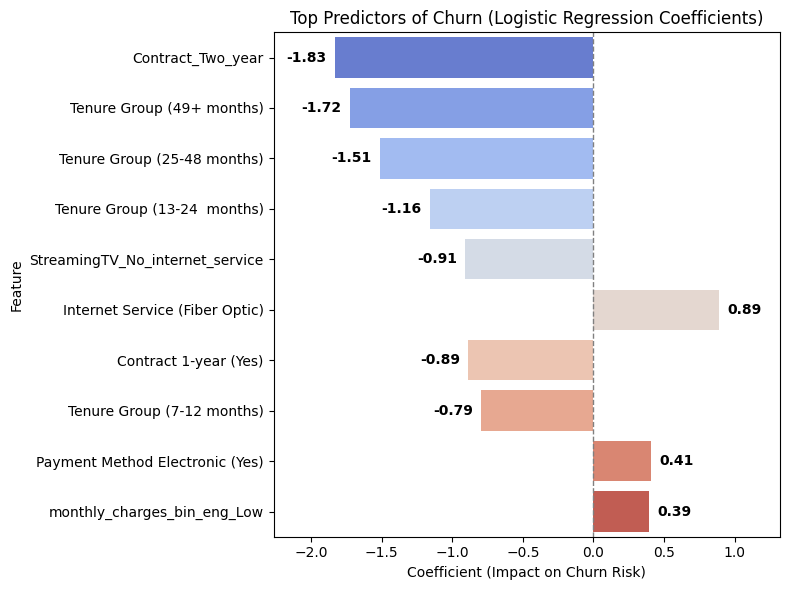

In [45]:
# Plot top predictors for churn from logistic regression model

top_n = 10
top_coef = coef_df_all_add_ons.head(top_n).copy()
plt.figure(figsize=(8, 6))  # Wide figure for more space
ax = sns.barplot(x='coefficient', y='readable_label', data=top_coef, palette='coolwarm', orient='h')
plt.title('Top Predictors of Churn (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Impact on Churn Risk)')
plt.ylabel('Feature')
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Set x-limits to add more space for annotation text
xlim = ax.get_xlim()
x_pad = 0.1 * (xlim[1] - xlim[0])
plt.xlim(xlim[0] - x_pad, xlim[1] + x_pad)

# Annotate each bar with its coefficient value, always outside the bar
for bar, coef in zip(ax.patches, top_coef['coefficient']):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    if x >= 0:
        text_x = x + 0.02 * (xlim[1] - xlim[0])
        ha = 'left'
    else:
        text_x = x - 0.02 * (xlim[1] - xlim[0])
        ha = 'right'
    ax.text(text_x, y, f'{coef:.2f}', va='center', ha=ha, color='black', fontsize=10, fontweight='bold', clip_on=False)

plt.tight_layout()
plt.savefig('../reports/figures/top_predictors_logreg_all_add_ons.png', bbox_inches='tight', dpi=300)
plt.show()

## 7. Interpretation of Top Coefficients

In logistic regression, each coefficient represents a change in the **log-odds** of churn.

- A **negative** coefficient indicates **lower churn odds** (retention-associated).
- A **positive** coefficient indicates **higher churn odds**.

All effects are interpreted *relative to the feature’s reference category*, since this model used one-hot encoding with `drop='first'`.

For interpretability, coefficients are often converted to **odds ratios** using exp(β):

- Values **< 1** decrease churn odds.
- Values **> 1** increase churn odds.

In this model’s top 10 coefficients, most are negative. This pattern is typical in churn modeling: many variables capture customer stability (contract type, tenure, bundled services), while churn risk tends to concentrate in smaller, higher-risk segments. Importantly, these reflect **associations**, not causal effects.

---

### Retention-Associated Factors

The strongest retention signals align with classic relationship variables:

#### Contract Length

Customers on **1-year** or **2-year** contracts have substantially lower churn odds compared with the reference category (**month-to-month**). Longer commitments make switching harder and may also reflect a more stable customer segment.

#### Tenure

All non-reference tenure bins (7–12, 13–24, 25–48, and 49+ months) show lower churn odds relative to the reference group (**0–6 months**). This reflects a common lifecycle pattern: churn risk is highest in the earliest months.

#### Online Security = Yes

Among add-on services, **Online Security = Yes** has one of the strongest negative coefficients (relative to **Online Security = No**). This likely identifies customers who perceive higher value from their service bundle, are more engaged, or have characteristics that make them less likely to switch. It may also function as a proxy for customer type, plan mix, or usage patterns.

#### “No Internet Service” Indicator

The “**No internet service**” variable appears with a negative coefficient in the top 10. This should be interpreted as a segment indicator, not as an effect specific to StreamingTV.

In this dataset, customers without internet service are labeled “No internet service” across all internet-based add-ons, so this variable effectively serves as a proxy for InternetService = No. The coefficient compares no-internet customers to those who have internet in the reference add-on category (e.g., “StreamingTV = No”).

---

### Churn-Associated Factors

The strongest positive coefficients identify higher-risk segments:

#### Internet Service = Fiber Optic

Compared with the reference category (**DSL**), fiber optic customers have higher churn odds. This may reflect pricing differences, competitive fiber markets, or higher expectations around performance and reliability.

#### Payment Method = Electronic Check

Relative to **Bank transfer (automatic)** (the reference), electronic check is associated with higher churn odds. This may capture differences in customer segment or billing behavior (e.g., lower autopay adoption), and may also reflect billing friction since payment must be made manually each month.

---

### Overall Interpretation

These coefficient patterns describe **which customer segments are more or less likely to churn under the model**. Their primary value lies in identifying actionable customer segments and informing targeted interventions. (e.g., targeted outreach to fiber + electronic check customers).


## 8. Documentation
This section documents the modeling decisions and evaluation protocol used in this notebook so results are reproducible and correctly interpreted.

**Objective / decision rule**
- Primary operating goal: **maximize recall** subject to **precision ≥ 0.50** (implemented as **0.52** with a small (0.02) buffer to reduce risk of failing the constraint on the test set).
- Also track threshold-free ranking performance via **ROC-AUC** and **Average Precision (AP / PR-AUC summary)**.

**Data & feature sets**
- Inputs: pre-split training/testing files in `data/processed/` (`X_train_final.csv`, `X_test_final.csv`, `y_train.csv`, `y_test.csv`).
- Compared multiple feature sets driven by EDA pruning: `pruned_features_monthly_charges_bin`, `pruned_features_internet_service`, and `pruned_features_all_add_ons`.
- Column-role manifest: `references/telco_column_role_manifest.csv`.
- LightGBM compatibility: feature names are sanitized (no modeling semantics change).

**Models & imbalance handling**
- Baseline: stratified `DummyClassifier` for a minimum performance bar.
- Logistic regression: regularized `LogisticRegression` with `class_weight='balanced'`, optimizing `scoring='average_precision' tuned with `GridSearchCV`.
- LightGBM: tuned with Optuna `LightGBMTunerCV`, using `scale_pos_weight = n_neg / n_pos` and optimizing `metric='average_precision'` with early stopping; seeds are set for reproducibility.

**Validation protocol (no test leakage)**
- Cross-validation uses `StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)`.
- Threshold selection is performed using **pooled out-of-fold (OOF) probabilities** from `cross_val_predict(..., method='predict_proba')` on the training set only.
- The chosen threshold is then applied **once** to the holdout test set after refitting the final model on the full training data.

**Model comparison outputs**
- Baseline OOF comparison at threshold `t = 0.50`: `reports/model_comparison_table_oof_baseline_thr.csv`.
- Constraint-based comparison (max recall with precision ≥ 0.52): `reports/constraint_table_oof.csv`.
- Final train-vs-test metrics table at the selected operating threshold: `reports/validation_test_metrics_summary.csv`.

**Final model and operating point**
- Selected model: **Logistic Regression — All Add-Ons** (best constrained OOF recall while meeting the precision constraint).
- Chosen operating threshold (from OOF constraint selection): **0.4856**.
- Observed performance at `t = 0.4856`:
  - Train (OOF): Recall **0.8167**, Precision **0.5202**, ROC-AUC **0.8463**, AP **0.6500**
  - Test (holdout): Recall **0.8155**, Precision **0.4864**, ROC-AUC **0.8342**, AP **0.6273**
- Note: recall generalizes well, but test precision fell below the 0.50 target at this threshold. The threshold was **not** re-tuned on the test set to avoid leakage; this is reported as generalization variability.

**Interpretability & artifacts**
- Coefficients are interpreted on the log-odds scale and reported as **odds ratios** ($\exp(\beta)$) relative to one-hot reference categories (`drop='first'`).
- Top predictors are exported to `reports/top_predictors_logreg_all_add_ons.csv` and visualized in `reports/figures/top_predictors_logreg_all_add_ons.png`.
- Mapping from model feature codes to readable labels uses `references/telco_column_role_manifest_with_labels.csv`.

**Future work**
- Consider more conservative threshold selection (larger buffer) or nested CV / bootstrap to quantify uncertainty on precision-at-threshold before deployment.
- Explore additional features or external data sources to improve separability (and therefore precision at high recall).

## 9. Outputs
**List of files saved in this notebook**

- [X_train_final_clean](../data/processed/X_train_final_clean.csv)
- [X_test_final_clean](../data/processed/X_test_final_clean.csv)
- [X_train_all_add_ons](../data/processed/X_train_all_add_ons.csv)
- [y_train](../data/processed/y_train.csv)
- [y_test](../data/processed/y_test.csv)
- [model_comparison_table_oof_baseline_thr](../reports/model_comparison_table_oof_baseline_thr.csv)
- [constraint_table_oof](../reports/constraint_table_oof.csv)
- [validation_test_metrics_summary](../reports/validation_test_metrics_summary.csv)
- [top_predictors_logreg_all_add_ons](../reports/top_predictors_logreg_all_add_ons.csv)
- [top_predictors_logreg_all_add_ons](../reports/figures/top_predictors_logreg_all_add_ons.png)